In [1]:
pip install pandas sklearn matplotlib seaborn graphviz openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\murli\taxonamy\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [ ]:
import pandas as pd
import re
from collections import defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# -----------------------------
# Load Data
# -----------------------------
input_file = "Security_Issues.xlsx"

# If your sheet name is "Security_Issues"
df = pd.read_excel(input_file, sheet_name="Security_Issues")

# Combine text fields
df["text"] = (
    df["issue_body"].fillna("") + " " +
    df["comments_text"].fillna("") + " " +
    df["threat_reason"].fillna("")
)

# -----------------------------
# Preprocess
# -----------------------------
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z ]", " ", text)
    return text

df["clean_text"] = df["text"].apply(clean_text)

# -----------------------------
# TF-IDF + Clustering
# -----------------------------
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
X = vectorizer.fit_transform(df["clean_text"])

k = 10  # number of clusters (tune this)
kmeans = KMeans(n_clusters=k, random_state=42)
df["cluster"] = kmeans.fit_predict(X)

# -----------------------------
# Extract Top Keywords per Cluster
# -----------------------------
terms = vectorizer.get_feature_names_out()
cluster_keywords = {}

for i in range(k):
    center = kmeans.cluster_centers_[i]
    top_idx = center.argsort()[-10:]
    cluster_keywords[i] = [terms[j] for j in top_idx]

print("\nCluster Keywords:")
for cid, words in cluster_keywords.items():
    print(f"Cluster {cid}: {words}")

# -----------------------------
# Map Clusters → Categories
# -----------------------------
cluster_to_category = {
    0: "API Security",
    1: "Secrets Management",
    2: "Code Security",
    3: "Data Integrity",
    4: "Model Security",
    5: "Validation Integrity",
    6: "Adversarial Attacks",
    7: "Dependency Risks",
    8: "Resource Abuse",
    9: "Privacy Risks"
}

df["category"] = df["cluster"].map(cluster_to_category)

# -----------------------------
# Normalize Stage Labels
# -----------------------------
def normalize_stage(stage):
    stage = str(stage).lower()
    if "acquisition" in stage:
        return "Acquisition"
    elif "preparation" in stage:
        return "Preparation"
    elif "model" in stage:
        return "Modeling"
    elif "train" in stage:
        return "Training"
    elif "eval" in stage:
        return "Evaluation"
    elif "predict" in stage:
        return "Prediction"
    return "Unknown"

df["stage"] = df["mlops_stage_tags"].apply(normalize_stage)

# -----------------------------
# Save Results to Excel
# -----------------------------
output_file = "classified_taxonomy.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    
    # Sheet 1: Full dataset
    df.to_excel(writer, sheet_name="Classified_Issues", index=False)
    
    # Sheet 2: Cluster Keywords
    keywords_df = pd.DataFrame([
        {"cluster": cid, "keywords": ", ".join(words)}
        for cid, words in cluster_keywords.items()
    ])
    keywords_df.to_excel(writer, sheet_name="Cluster_Keywords", index=False)
    
    # Sheet 3: Stage Distribution
    stage_dist = df["stage"].value_counts().reset_index()
    stage_dist.columns = ["Stage", "Count"]
    stage_dist.to_excel(writer, sheet_name="Stage_Distribution", index=False)

print(f"Saved results to {output_file}")


Cluster Keywords:
Cluster 0: ['contains', 'issue', 'marked', 'strong', 'signals', 'evidence', 'lacks', 'vulnerability', 'cve', 'kedro']
Cluster 1: ['data', 'pcap', 'zeek', 'pid', 'alerts', 'costs', 'flows', 'total', 'celavi', 'slips']
Cluster 2: ['feedback', 'token', 'train', 'trulens', 'key', 'test', 'api', 'openai', 'data', 'anomalib']
Cluster 3: ['python', 'tokenizer', 'config', 'import', 'file', 'py', 'pretrained', 'torch', 'transformers', 'model']
Cluster 4: ['pip', 'site', 'packages', 'python', 'build', 'file', 'line', 'py', 'lib', 'xformers']
Cluster 5: ['py', 'client', 'step', 'pipeline', 'python', 'google', 'stack', 'store', 'server', 'zenml']
Cluster 6: ['image', 'error', 'docker', 'issue', 'python', 'py', 'haystack', 'data', 'gradio', 'file']
Cluster 7: ['import', 'secret', 'apiserver', 'kubeflow', 'task', 'server', 'dsl', 'pipeline', 'clearml', 'kfp']
Cluster 8: ['device', 'attention', 'torch', 'token', 'input', 'mask', 'tokens', 'tokenizer', 'ids', 'model']
Cluster 9: ['x

In [ ]:
import pandas as pd
import re
from collections import defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# -----------------------------
# Load Data
# -----------------------------
df = pd.read_csv("security_issues.csv")

# Combine text fields
df["text"] = (
    df["issue_body"].fillna("") + " " +
    df["comments_text"].fillna("") + " " +
    df["threat_reason"].fillna("")
)

# -----------------------------
# Preprocess
# -----------------------------
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z ]", " ", text)
    return text

df["clean_text"] = df["text"].apply(clean_text)

# -----------------------------
# TF-IDF + Clustering
# -----------------------------
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
X = vectorizer.fit_transform(df["clean_text"])

k = 10  # number of clusters (tune this)
kmeans = KMeans(n_clusters=k, random_state=42)
df["cluster"] = kmeans.fit_predict(X)

# -----------------------------
# Extract Top Keywords per Cluster
# -----------------------------
terms = vectorizer.get_feature_names_out()
cluster_keywords = {}

for i in range(k):
    center = kmeans.cluster_centers_[i]
    top_idx = center.argsort()[-10:]
    cluster_keywords[i] = [terms[j] for j in top_idx]

print("\nCluster Keywords:")
for cid, words in cluster_keywords.items():
    print(f"Cluster {cid}: {words}")

# -----------------------------
# Map Clusters → Categories (Manual step once)
# -----------------------------
cluster_to_category = {
    0: "API Security",
    1: "Secrets Management",
    2: "Code Security",
    3: "Data Integrity",
    4: "Model Security",
    5: "Validation Integrity",
    6: "Adversarial Attacks",
    7: "Dependency Risks",
    8: "Resource Abuse",
    9: "Privacy Risks"
}

df["category"] = df["cluster"].map(cluster_to_category)

# -----------------------------
# Normalize Stage Labels
# -----------------------------
def normalize_stage(stage):
    stage = str(stage).lower()
    if "acquisition" in stage:
        return "Acquisition"
    elif "preparation" in stage:
        return "Preparation"
    elif "model" in stage:
        return "Modeling"
    elif "train" in stage:
        return "Training"
    elif "eval" in stage:
        return "Evaluation"
    elif "predict" in stage:
        return "Prediction"
    return "Unknown"

df["stage"] = df["mlops_stage_tags"].apply(normalize_stage)

# -----------------------------
# Save Results
# -----------------------------
df.to_csv("classified_taxonomy.csv", index=False)
print("Saved classified_taxonomy.csv")


Cluster Keywords:
Cluster 0: ['contains', 'issue', 'marked', 'strong', 'signals', 'evidence', 'lacks', 'vulnerability', 'cve', 'kedro']
Cluster 1: ['data', 'pcap', 'zeek', 'pid', 'alerts', 'costs', 'flows', 'total', 'celavi', 'slips']
Cluster 2: ['feedback', 'token', 'train', 'trulens', 'key', 'test', 'api', 'openai', 'data', 'anomalib']
Cluster 3: ['python', 'tokenizer', 'config', 'import', 'file', 'py', 'pretrained', 'torch', 'transformers', 'model']
Cluster 4: ['pip', 'site', 'packages', 'python', 'build', 'file', 'line', 'py', 'lib', 'xformers']
Cluster 5: ['py', 'client', 'step', 'pipeline', 'python', 'google', 'stack', 'store', 'server', 'zenml']
Cluster 6: ['image', 'error', 'docker', 'issue', 'python', 'py', 'haystack', 'data', 'gradio', 'file']
Cluster 7: ['import', 'secret', 'apiserver', 'kubeflow', 'task', 'server', 'dsl', 'pipeline', 'clearml', 'kfp']
Cluster 8: ['device', 'attention', 'torch', 'token', 'input', 'mask', 'tokens', 'tokenizer', 'ids', 'model']
Cluster 9: ['x

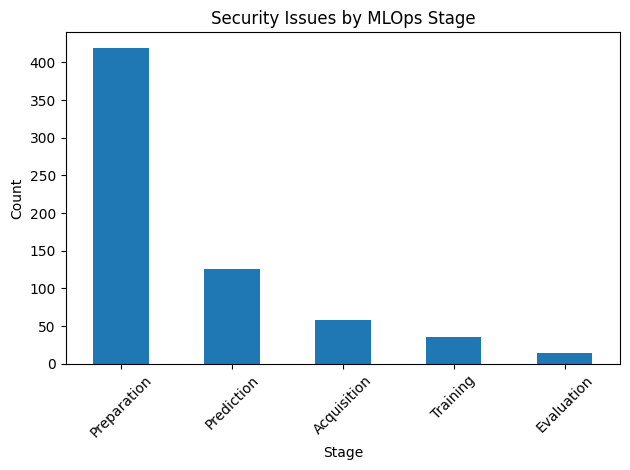

In [4]:
stage_counts = df["stage"].value_counts()

plt.figure()
stage_counts.plot(kind="bar")
plt.title("Security Issues by MLOps Stage")
plt.xlabel("Stage")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("stage_distribution.png")

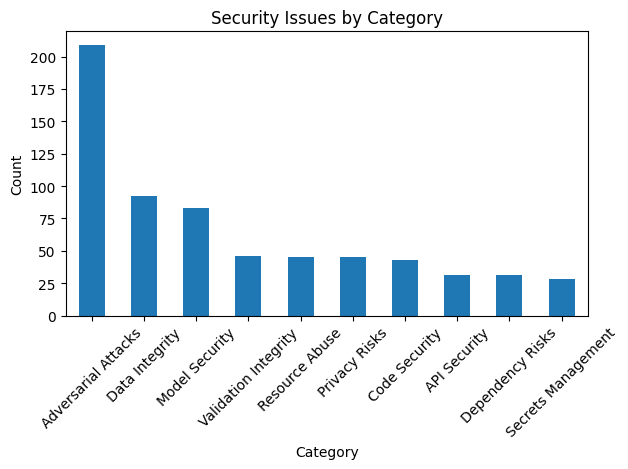

In [5]:
cat_counts = df["category"].value_counts()

plt.figure()
cat_counts.plot(kind="bar")
plt.title("Security Issues by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("category_distribution.png")

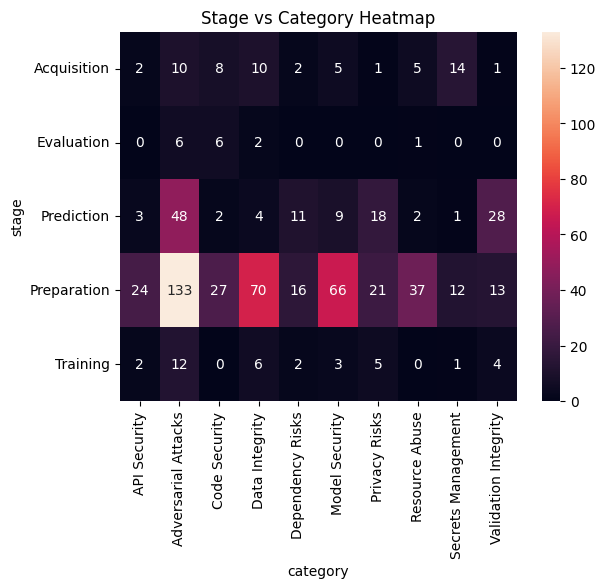

In [6]:
import seaborn as sns

pivot = pd.crosstab(df["stage"], df["category"])

plt.figure()
sns.heatmap(pivot, annot=True, fmt="d")
plt.title("Stage vs Category Heatmap")
plt.savefig("heatmap.png")

In [3]:
from graphviz import Digraph

dot = Digraph()

dot.node("MLOps Security Taxonomy")
dot.edge("MLOps Security Taxonomy", "Acquisition")
dot.edge("Acquisition", "Data Integrity")
dot.edge("Acquisition", "Source Trust")
dot.edge("MLOps Security Taxonomy", "Preparation")
dot.edge("Preparation", "Data Leakage")
dot.edge("Preparation", "Code Security")
dot.edge("Preparation", "Dependency Risks")
dot.edge("MLOps Security Taxonomy", "Modeling")
dot.edge("Modeling", "Model Security")
dot.edge("Modeling", "Configuration Security")
dot.edge("MLOps Security Taxonomy", "Training")
dot.edge("Training", "Secrets Management")
dot.edge("Training", "Resource Abuse")
dot.edge("Training", "Data Poisoning")
dot.edge("MLOps Security Taxonomy", "Evaluation")
dot.edge("Evaluation", "Validation Integrity")
dot.edge("Evaluation", "Robustness Gaps")
dot.edge("MLOps Security Taxonomy", "Prediction")
dot.edge("Prediction", "API Security")
dot.edge("Prediction", "Model Attacks")
dot.edge("Prediction", "Privacy Attacks")

dot.render("taxonomy_tree", format="png")

'taxonomy_tree.png'